## Grab the 0.8 optical model file

In [1]:
import sys, os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy import units as u
import image_utils as iu
from astropy.coordinates import SkyCoord
from grism_sim_psf_dependent import mk_grism

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["image.interpolation"] = "nearest"
mpl.rcParams["image.origin"] = "lower"

github_dir = os.getenv('github_dir')
if github_dir is None:
    print('github_dir environment variable has not been set, will cause problems if not explicitly set in function calss')

/Users/keith/miniconda3/envs/grizli1/lib/python3.12/site-packages/pysynphot/refs.py:117: UserWarning: No graph or component tables found; functionality will be SEVERELY crippled. No files found for /Users/keith/astr/research/env_data_dir/PYSYN_CDBS/mtab/*_tmg.fits
  warnings.warn('No graph or component tables found; '
/Users/keith/miniconda3/envs/grizli1/lib/python3.12/site-packages/pysynphot/refs.py:124: UserWarning: No thermal tables found, no thermal calculations can be performed. No files found for /Users/keith/astr/research/env_data_dir/PYSYN_CDBS/mtab/*_tmt.fits
  warnings.warn('No thermal tables found, '


In [2]:
outdir = "/Users/keith/astr/research/SCRATCH/bin"

ind =   [0,       1]            # index
tmp =   [154.0,   154.0]        # star_template_index
mag =   [1.0,     1.0]          # magnitude
RA =    [9.4,     9.45]        # RA
DEC =   [1.05,   1.025]          # DEC

star_input = Table([ind, tmp, mag, RA, DEC],
               names=("index", "star_template_index", "magnitude", "RA", "DEC"))

det_num = 1

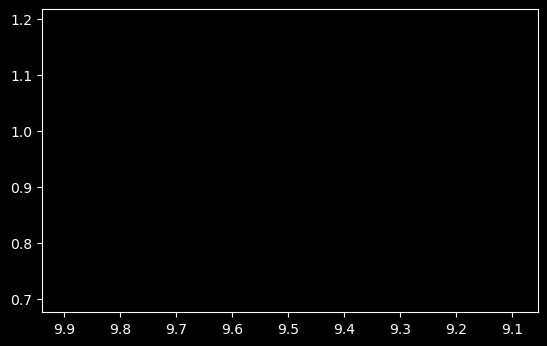

In [3]:
tel_ra = 9.5
tel_dec = 1
pa = 0

sys.path.append(github_dir+'/observing-program/py')
import grism_dispersion
import roman_coords_transform as ctrans
code_data_dir = github_dir+'/observing-program/data/'
rctrans = ctrans.RomanCoordsTransform(file_path=code_data_dir)
dfoot = rctrans.wfi_sky_pointing(tel_ra, tel_dec, pa+60, ds9=False)
ra = dfoot[0][int(det_num)]['ra_cen']
dec = dfoot[0][int(det_num)]['dec_cen']

tot_im_size = 4088+2*1000 

im_head = iu.fake_header_wcs(ra, dec, crpix2=tot_im_size/2,crpix1=tot_im_size/2,crota2=pa,naxis1=tot_im_size,naxis2=tot_im_size)
im_wcs = WCS(im_head)

star_coords = SkyCoord(ra=star_input['RA']*u.degree,dec=star_input['DEC']*u.degree, frame='icrs')
star_xy = im_wcs.world_to_pixel(star_coords)

xc = int(star_xy[0][0]) - 1000
yc = int(star_xy[1][0]) - 1000

In [4]:
theta =  np.pi / 2

x_rot = int((np.cos(theta) * (xc-2044) - np.sin(theta) * (yc-2044)) + 2044)
y_rot = int((np.sin(theta) * (xc-2044) + np.cos(theta) * (yc-2044)) + 2044)

print(xc, yc)
print(x_rot, y_rot)

2991 2468
1620 2991


In [5]:
test_array = np.zeros((4088, 4088))

test_array[int(y_rot), int(x_rot)] += 5

print(np.any(test_array))

sub_array = np.zeros((4088, 4088))
sub_array[yc, xc] -= 5
sub_array = np.rot90(sub_array, k=3)

print(np.any(sub_array))

print(np.any(test_array + sub_array))

True
True
True


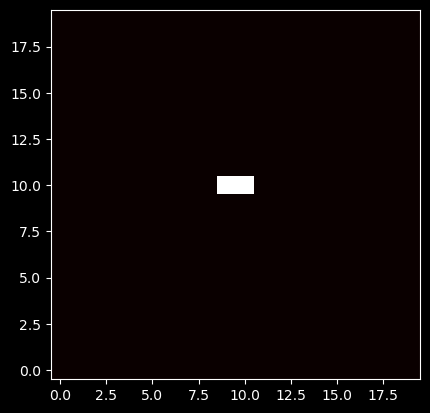

In [6]:
plt.imshow((test_array - sub_array)[y_rot-10:y_rot+10, x_rot-10:x_rot+10], vmin=0, vmax=5, cmap="hot", origin="lower")

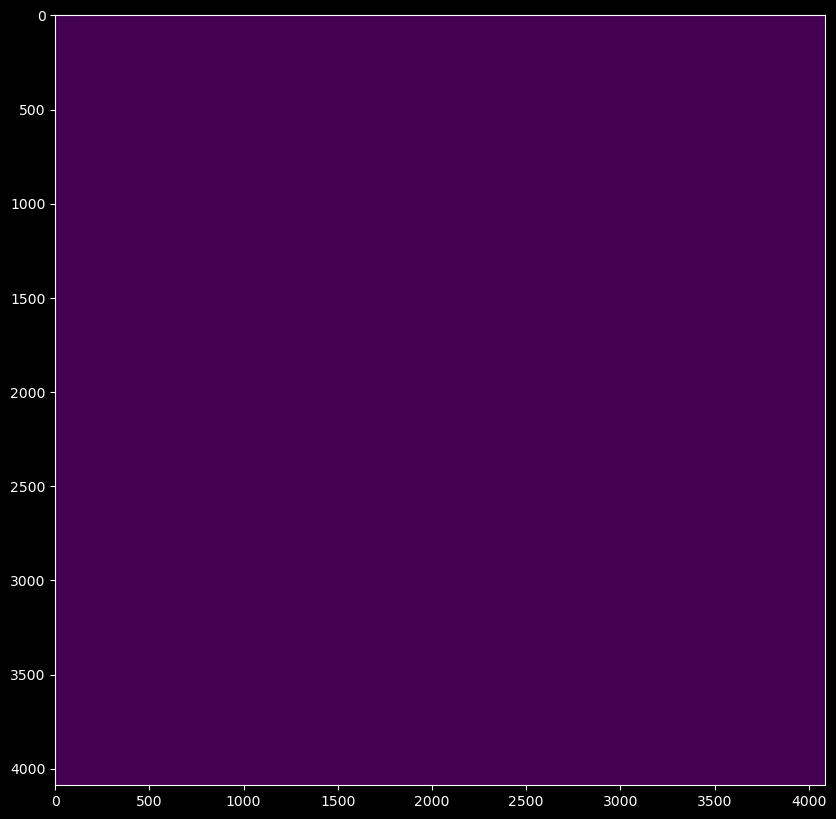

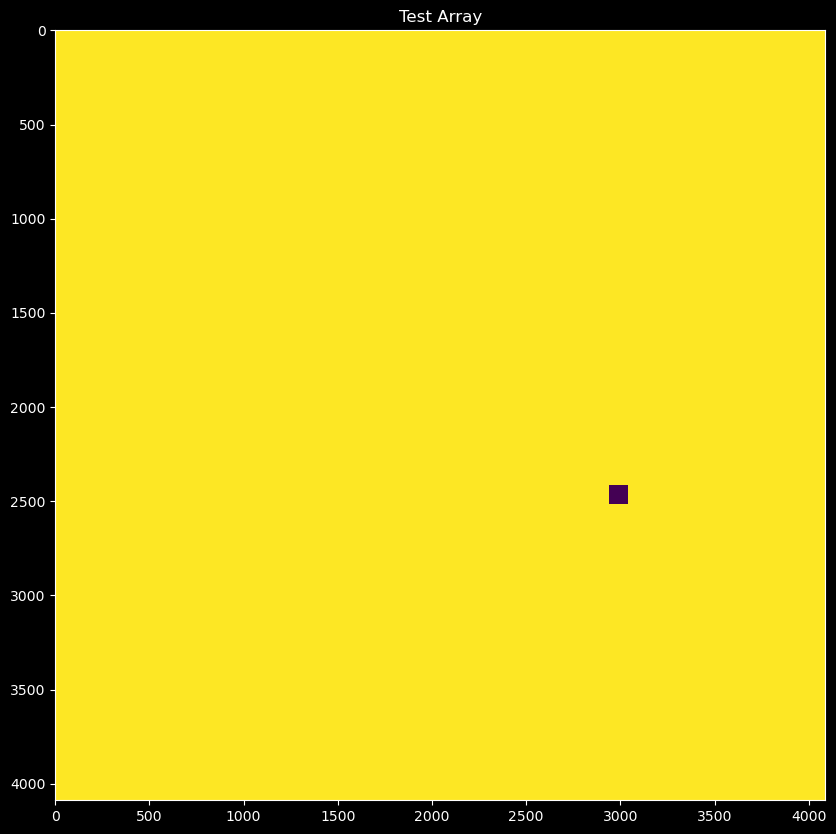

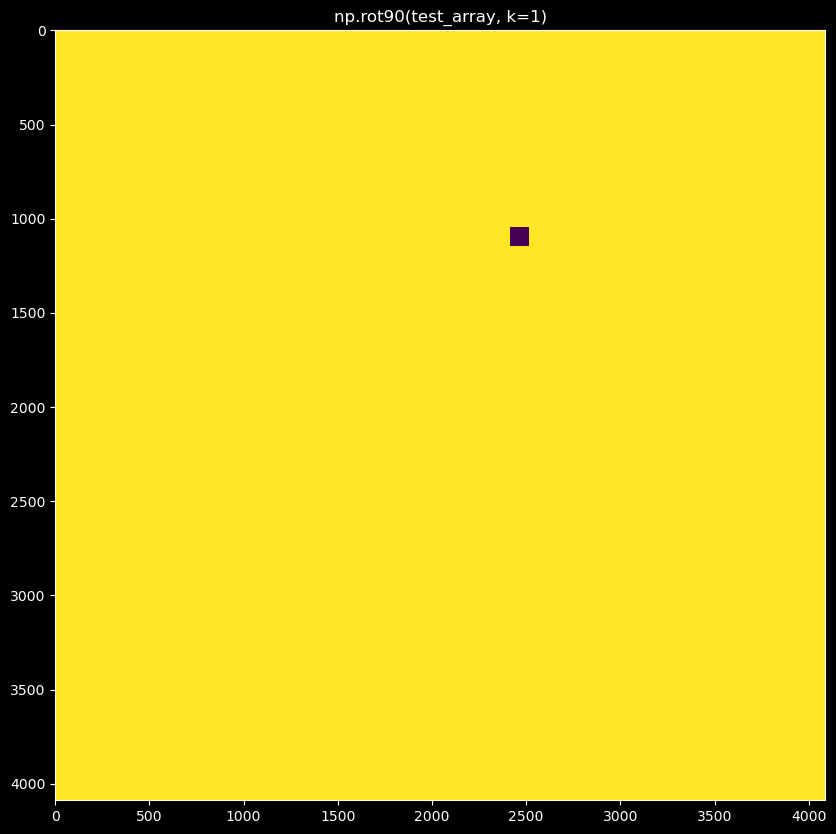

In [7]:
mpl.rcParams["figure.figsize"] = (10,10)
mpl.rcParams["image.origin"] = "upper"
test_array_2 = np.zeros((4088, 4088))
test_array_2[y_rot-50:y_rot+50, x_rot-50:x_rot+50] += 5
plt.imshow(test_array)
plt.show()

sub_array_2 = np.zeros((4088, 4088))
sub_array_2[yc-50:yc+50, xc-50:xc+50] -= 5
plt.imshow(sub_array_2)
plt.title("Test Array")
plt.show()
plt.imshow(np.rot90(sub_array_2, k=1))
plt.title("np.rot90(test_array, k=1)")
plt.show()

In [8]:
grizli_conf = grism_dispersion.aXeConf(conf_file="/Users/keith/astr/research/grism_sim/data/testbuild/TestBuild_rot_det1.conf")
# grizli_conf = grism_dispersion.aXeConf(conf_file="/Users/keith/astr/research_astr/grism_sim/data/Roman.det1.03192025.conf")

dx = np.flip(np.arange(-380, 624, 1))

beam = grizli_conf.get_beam_trace(x=x_rot, y=y_rot, dx=dx)

beam

(array([-22.81165791, -22.8215833 , -22.83151008, ..., -32.62516447,
        -32.63444574, -32.64372545]),
 array([ 9100.6398717 ,  9100.6398717 ,  9111.60640654, ...,
        20097.67944143, 20108.684995  , 20119.69058741]))

In [9]:
import sys
sys.path.insert(0, "/Users/keith/astr/research/roman_disperser/src")
from roman_disperser import optical_model

wfi_siaf = iu.get_wfi_siaf(tel_ra, tel_dec, pa, 1)
xc_fpa, yc_fpa = wfi_siaf.sci_to_idl(xc, yc)

optmod = optical_model.RomanOpticalModel(config_file="/Users/keith/astr/research/roman_disperser/data/Roman_grism_OpticalModel_v0.8.yaml")
optical = optmod._get_beam_trace(*optmod.coords.convert_sca_to_fpa(xc, yc, 1), det_num)

In [10]:
model = mk_grism(tel_ra, tel_dec, pa, det_num, star_input, None, outdir, 
                 dogal='n', mockdir=outdir, confver="03192025_rotAonly")

checkpoint_0
checkpoint_1


 [astropy.io.fits.verify]


checkpoint_2
checkpoint_3
checkpoint_4




Image cutout: x=slice(0, 6088, None), y=slice(0, 6088, None) [Out of range]
/Users/keith/astr/research/SCRATCH/bin/empty_grism_ra9.5_dec1_pa0_detSCA01.fits / blot reference /Users/keith/astr/research/SCRATCH/bin/refimage_ra9.5_dec1_pa0_detSCA01_nopad.fits[0]
The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    
The following tasks in the drizzlepac package can be run with TEAL:
    astrodrizzle       config_testbed      imagefindpars           mapreg       
       photeq            pixreplace           pixtopix            pixtosky      
  refimagefindpars       resetbits          runastrodriz          skytopix      
     tweakback            tweakreg           updatenpol
Using default C-based coordinate transformation...
checkpoint_5
starting at 10000.0
adding stars to model
starting at 10500.0
adding stars to model
starting at 11000.0
adding stars to model
starting at 11500.0
adding stars t

In [11]:
fp = os.path.join(outdir, f"grism_ra{tel_ra}_dec{tel_dec}_pa{pa}_detSCA{det_num:02d}.fits")
file = fits.open(fp)

In [12]:
grizli_beam_x = xc+beam[0]
grizli_beam_y = yc-dx # -dx (as opposed to +dx) is due to the rotations applied before dispersion

In [13]:
from matplotlib.colors import ListedColormap
c1 = "black"
c2 = "gray"
c3 = "red"
c4 = "tab:gray"
cmap = ListedColormap([c1, c2, c3, c4])

import matplotlib.patches as mpatches
legend_patches = [
    # mpatches.Patch(color=c2, label='Dispersion Model'),
    mpatches.Patch(color=c3, label='Optical Model Trace'),
    mpatches.Patch(color=c4, label='Grizli Beam Trace'),
]

In [14]:
optical

{'optical_element': 'grism',
 'order': '1',
 'ref_pos_fpa': [-0.09657083333333334, 0.050065277777777785],
 'ref_pos_mpa': [-31.605000000000004, 16.385],
 'ref_pos_sca': [2991.0000000000005, 2468.0],
 'sca': 1,
 'width': 1,
 'ref_trace_fpa': array([[[-0.09569589],
         [ 0.04886107]]]),
 'ref_trace_mpa': array([[-31.31865514,  15.99089542]]),
 'ref_trace_sca': array([[2962.36551371, 2428.58954161]]),
 'crv': array([[-5.19976754e-07],
        [ 9.80504201e-03],
        [-5.15562559e-05],
        [-1.87081096e-06],
        [ 1.61748038e-07],
        [-2.79371172e-08]]),
 'ids': array([[-8.43467668e-06],
        [ 9.11885387e+00],
        [ 4.52507529e-02],
        [ 4.05534873e-02],
        [-3.73331597e-02],
        [ 7.37779746e-02]]),
 'trace_mpa_x': array([[-31.3778622 , -31.37256424, -31.36725455, -31.36194045,
         -31.3566281 , -31.35132266, -31.34602846, -31.34074911,
         -31.3354876 , -31.33024642, -31.32502761, -31.31983286,
         -31.31466357, -31.30952094, -31.

In [15]:
print(xc+dx,yc+beam[0].astype(int))

[3614 3613 3612 ... 2613 2612 2611] [2446 2446 2446 ... 2436 2436 2436]


In [16]:
optical["trace_sca_y"].min()

1835.1388815584673

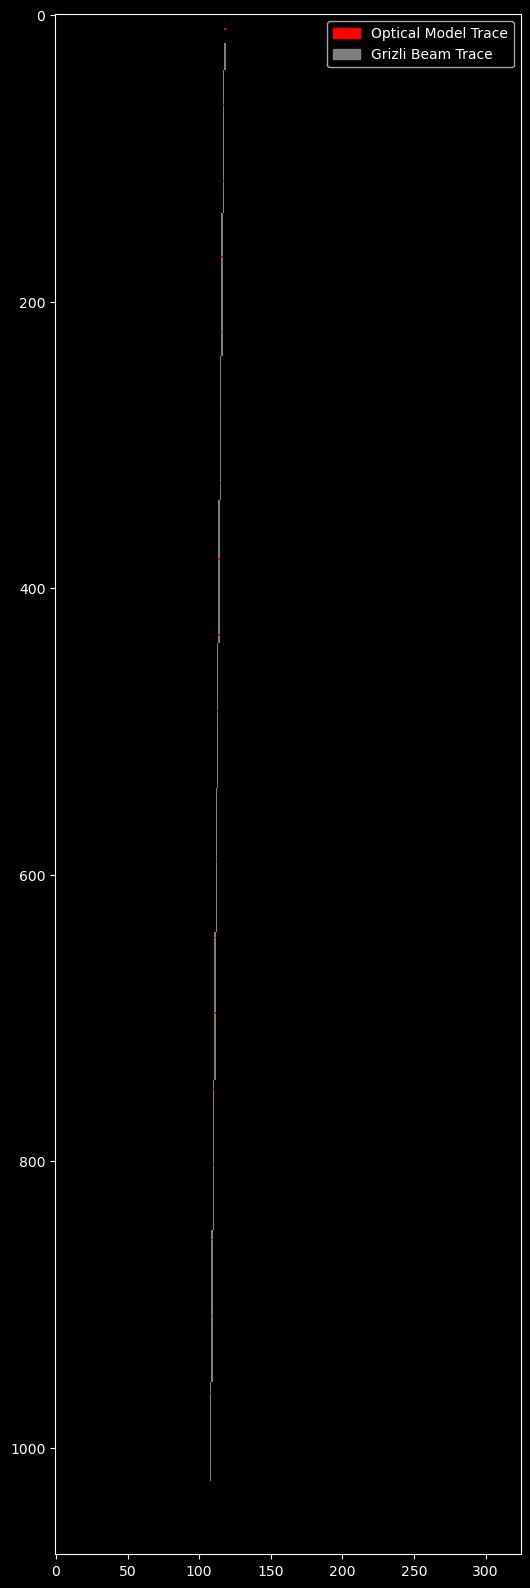

In [17]:
mpl.rcParams["figure.figsize"] = [20, 20]
model = file[4].data

seg = np.zeros_like(model)
seg[np.where(model != 0)] = 1

seg[grizli_beam_y.astype(int), grizli_beam_x.astype(int)] = 3

seg[optical["trace_sca_y"][0].astype(int), optical["trace_sca_x"][0].astype(int)] = 2

plt.imshow(seg[1825:2900, 2850:3175], cmap=cmap, vmin=0, vmax=3)
plt.legend(handles=legend_patches, loc='upper right', fontsize=10, frameon=True)

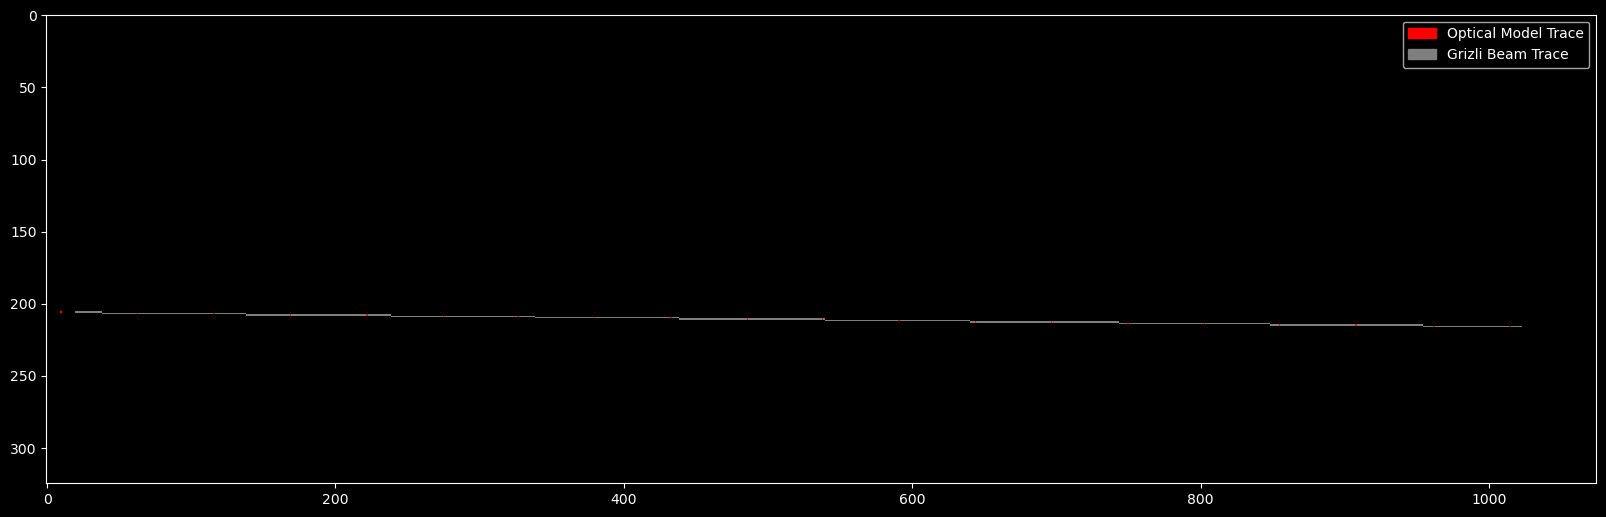

In [18]:
mpl.rcParams["figure.figsize"] = [20, 20]
model = file[4].data

seg = np.zeros_like(model)
seg[np.where(model != 0)] = 1

seg[grizli_beam_y.astype(int), grizli_beam_x.astype(int)] = 3

seg[optical["trace_sca_y"][0].astype(int), optical["trace_sca_x"][0].astype(int)] = 2

rot_seg = np.rot90(seg)

plt.imshow(rot_seg[913:1238, 1825:2900], cmap=cmap, vmin=0, vmax=4)
plt.legend(handles=legend_patches, loc='upper right', fontsize=10, frameon=True)

In [19]:
x_rot = (np.cos(theta) * (2900-2044) - np.sin(theta) * (3175-2044)) + 2044
y_rot = (np.sin(theta) * (2900-2044) + np.cos(theta) * (3175-2044)) + 2044

print(x_rot, y_rot)

913.0 2900.0


In [20]:
print(grizli_beam_x)
print(grizli_beam_y)

[2968.18834209 2968.1784167  2968.16848992 ... 2958.37483553 2958.36555426
 2958.35627455]
[1845 1846 1847 ... 2846 2847 2848]


In [21]:
optical

{'optical_element': 'grism',
 'order': '1',
 'ref_pos_fpa': [-0.09657083333333334, 0.050065277777777785],
 'ref_pos_mpa': [-31.605000000000004, 16.385],
 'ref_pos_sca': [2991.0000000000005, 2468.0],
 'sca': 1,
 'width': 1,
 'ref_trace_fpa': array([[[-0.09569589],
         [ 0.04886107]]]),
 'ref_trace_mpa': array([[-31.31865514,  15.99089542]]),
 'ref_trace_sca': array([[2962.36551371, 2428.58954161]]),
 'crv': array([[-5.19976754e-07],
        [ 9.80504201e-03],
        [-5.15562559e-05],
        [-1.87081096e-06],
        [ 1.61748038e-07],
        [-2.79371172e-08]]),
 'ids': array([[-8.43467668e-06],
        [ 9.11885387e+00],
        [ 4.52507529e-02],
        [ 4.05534873e-02],
        [-3.73331597e-02],
        [ 7.37779746e-02]]),
 'trace_mpa_x': array([[-31.3778622 , -31.37256424, -31.36725455, -31.36194045,
         -31.3566281 , -31.35132266, -31.34602846, -31.34074911,
         -31.3354876 , -31.33024642, -31.32502761, -31.31983286,
         -31.31466357, -31.30952094, -31.

In [22]:
print("x min pixel: ", grizli_beam_x[0] - optical["trace_sca_x"][0][0])
print("x max pixel  ", grizli_beam_x[-1] - optical["trace_sca_x"][0][-1])
print("y min pixel: ", grizli_beam_y[0] - optical["trace_sca_y"][0][0])
print("y max pixel: ", grizli_beam_y[-1] - optical["trace_sca_y"][0][-1])

x min pixel:  -0.0978783471286988
x max pixel   -0.07242965934528911
y min pixel:  9.861118441532653
y max pixel:  7.79395446033368
